In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point

import matplotlib.pyplot as plt
import contextily as ctx

from dataclasses import dataclass, field, fields

os.chdir("c:/Users/Administrator/Desktop/Uni Landau/Master/4. Semester/ACP4/ACP4")

In [2]:
from src.config.config import Config
from src.data.read_data import Data, read_camel_data, read_agro_data
from src.data.check_data import print_data_length, check_missing_values, plot_daily_flow

config = Config()

## 1. Data availability and quality checks

In [6]:
df_camel = read_camel_data(
    timeseries_dir=config.timeseries_dir, 
    gauge_id=config.gauge_id
    )

dfs_agro = read_agro_data(timeseries_dir=config.agrometeo_dir)

data = Data(
    camel=df_camel,
    agro_herxheimweyher=dfs_agro["herxheimweyher"],
    agro_steinweiler=dfs_agro["steinweiler"]
)

In [ ]:
# Question 1.1
print_data_length(data=data)

Name: camel
Length of available data:
25567 days 00:00:00
------------------------
Name: agro_herxheimweyher
Length of available data:
730 days 00:00:00
------------------------
Name: agro_steinweiler
Length of available data:
730 days 00:00:00
------------------------


In [24]:
# Question 1.3
check_missing_values(data=data)

Name: camel
Number of NAs:
discharge_vol_obs     3234
discharge_spec_obs    3234
water_level_obs       2529
dtype: int64
Percentage of NAs:
discharge_vol_obs     12.65
discharge_spec_obs    12.65
water_level_obs        9.89
dtype: float64%
------------------------
Name: agro_herxheimweyher
No missing values.
------------------------
Name: agro_steinweiler
No missing values.
------------------------


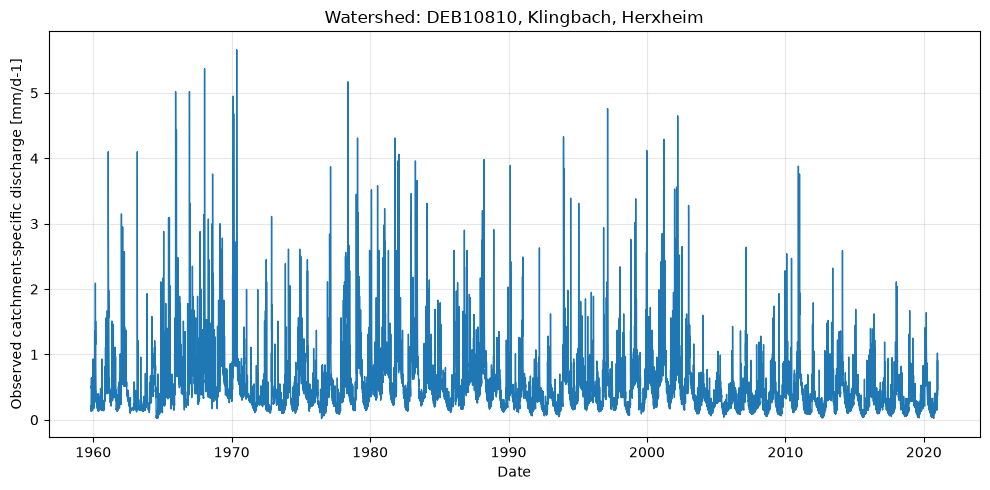

In [9]:
plot_daily_flow(df=data.camel)